# News mentions, article-count size proxy, and stock reaction

This notebook tests whether companies with lower news visibility react more strongly to article mentions than companies with high news visibility.

The financial question is:

```text
When a company is mentioned in an article, does its stock move more after the mention than before it, and is this effect stronger for low-article-count companies?
We use article_count as the main size/visibility proxy. Companies with low article count are interpreted as less visible or less frequently covered, while companies with high article count are interpreted as more visible and more frequently covered.
```
The main outcome is the change in absolute stock return around the article date:
```text
abs_change = |return after the mention| - |return before the mention|
```
A positive value means the stock moved more after the mention than before it.

## Methodology

The analysis starts from article-level company mentions and daily stock returns.

First, raw company names from the articles are normalised and mapped to stock tickers. We then build a table of ticker-date events, where each row represents one ticker being mentioned on one date.

Next, we classify companies using article count:

```text
bottom tercile of article_count -> small / low visibility
top tercile of article_count    -> large / high visibility
The middle tercile is excluded from the main comparison so that the test focuses on the clearest contrast.
```

For each ticker-date event, we align the article date with the trading calendar and compute:
```text
ret_m1 = stock return on the previous trading day
ret_p1 = stock return on the next trading day
abs_change = |ret_p1| - |ret_m1|
```
Then we aggregate the event-level reactions to one row per ticker:
```text
mean_abs_change = average(abs_change across all mention dates for that ticker)
This prevents frequently mentioned companies from dominating the statistical test.
```

Finally, we compare mean_abs_change between low-article-count and high-article-count companies. The main test is Welch's two-sample t-test when variances are unequal, with Mann-Whitney reported as a robustness check.


In [13]:
from pathlib import Path
import ast
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

HERE = Path('.').resolve()
PROJECT = HERE.parents[1]
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

MIN_EVENTS_PER_TICKER = 3
SIZE_GROUPS = ['small', 'large']

## 1. Load article mentions, graph company table, and daily returns

In [14]:
articles = pd.read_csv(PROJECT / 'companies_in_articles.csv')
company_db = pd.read_csv(PROJECT / 'nyse_nasdaq_companies_list.csv')
graph_nodes = pd.read_csv(HERE / 'louvain_clusters_with_industries_degrees_ranks.csv')
article_counts = pd.read_csv(HERE / 'company_article_counts.csv')
daily_ret = pd.read_csv(HERE / 'daily_returns_2017_2019.csv', index_col=0, parse_dates=True)

articles['date'] = pd.to_datetime(articles['date'], errors='coerce')
articles = articles.dropna(subset=['date'])

print(f'articles with dates: {len(articles):,}')
print(f'graph company rows: {len(graph_nodes):,}')
print(f'article-count rows: {len(article_counts):,}')
print(f'daily return panel: {daily_ret.shape[0]:,} days x {daily_ret.shape[1]:,} tickers')

articles with dates: 48,259
graph company rows: 1,172
article-count rows: 2,562
daily return panel: 752 days x 724 tickers


## 2. Build mention-name to ticker mapping

The article file stores company mentions as raw strings. We normalize those strings and map them to tickers through the company database. Ambiguous aliases are removed.

In [15]:
LEGAL_SUFFIXES = r"""
inc|inc\.|corporation|corp|corp\.|company|co|co\.|group|plc|ltd|ltd\.|limited|
holdings|holding|sa|s\.a\.|ag|nv|n\.v\.|se|spa|s\.p\.a\.|asa|ab|gmbh|lp|llp|llc|l\.l\.c\.|bv|b\.v\.
"""
suffix_re = re.compile(rf'\b({LEGAL_SUFFIXES})\b', re.IGNORECASE | re.VERBOSE)

def normalize_name(x):
    if pd.isna(x):
        return None
    x = str(x).strip()
    if not x:
        return None
    x = x.replace("'s", '')
    x = re.sub(r'\.[A-Z]+$', '', x)
    x = x.lower().replace('&', ' and ')
    x = suffix_re.sub(' ', x)
    x = re.sub(r'[^a-z0-9 ]+', ' ', x)
    x = re.sub(r'\s+', ' ', x).strip()
    return x or None

alias_rows = []
for _, row in company_db.iterrows():
    for col in ['company', 'search_name', 'ticker']:
        if col not in company_db.columns:
            continue
        alias = normalize_name(row.get(col))
        ticker = row.get('ticker')
        if alias and len(alias) >= 3 and pd.notna(ticker):
            alias_rows.append((alias, str(ticker).strip()))

alias_df = pd.DataFrame(alias_rows, columns=['alias', 'ticker']).drop_duplicates()
alias_df = alias_df[alias_df['ticker'].str.len() > 0]
n_tickers_per_alias = alias_df.groupby('alias')['ticker'].nunique()
alias_df = alias_df[alias_df['alias'].isin(n_tickers_per_alias[n_tickers_per_alias == 1].index)]
alias_to_ticker = dict(zip(alias_df['alias'], alias_df['ticker']))

print(f'unambiguous aliases: {len(alias_to_ticker):,}')

unambiguous aliases: 7,154


## 3. Build ticker-date mention events

This step maps raw company mentions in articles to stock tickers.

One article can create several rows if it mentions several companies. However, duplicate mentions of the same ticker in the same article are kept only once.

We then collapse multiple articles mentioning the same ticker on the same date into one event. Dates can still repeat across different tickers. The final unit is:

```text
one ticker-date pair
```

In [16]:
def parse_company_list(x):
    if pd.isna(x):
        return []
    s = str(x)
    if s.startswith('['):
        try:
            parsed = ast.literal_eval(s)
            return parsed if isinstance(parsed, list) else []
        except Exception:
            return []
    return [s]

rows = []
for article_id, date, raw_companies in zip(articles['article_id'], articles['date'], articles['company']):
    seen = set()
    for company in parse_company_list(raw_companies):
        ticker = alias_to_ticker.get(normalize_name(company))
        if ticker and ticker in daily_ret.columns and ticker not in seen:
            seen.add(ticker)
            rows.append((article_id, date.normalize(), ticker))

mention_events = pd.DataFrame(rows, columns=['article_id', 'article_date', 'ticker'])
mention_events = mention_events.drop_duplicates(['article_date', 'ticker']).reset_index(drop=True)

print(f'unique ticker-date mention events: {len(mention_events):,}')
mention_events.head()

unique ticker-date mention events: 9,554


,article_id,article_date,ticker
0,0,2018-04-26,HMC
1,2,2018-04-10,C
2,6,2018-05-04,ALK
3,7,2018-05-08,BCRX
4,8,2018-05-31,PSO


## 4. Define article-count size groups

This step builds the size/visibility proxy used in the test.

We merge the graph company table with `company_article_counts.csv` so each ticker has an `article_count`. Since market capitalization is missing for many companies, we use article count as the main proxy for company visibility and size.

Companies are split into three terciles based on article count:

```text
bottom third  -> small / low visibility
middle third  -> middle
top third     -> large / high visibility
```

The main test later keeps only the `small` and `large` groups to compare the two extremes.

The code displays the first three rows after each transformation so we can verify how the table changes step by step.
```


In [17]:
article_counts_keep = article_counts[['company_id', 'article_count']].copy()
print('Step 1 - article count input:')
display(article_counts_keep.head(3))

size_table = graph_nodes[['company_id', 'ticker', 'company', 'industry_group', 'market_cap', 'pagerank']].copy()
print('Step 2 - graph metadata before merge:')
display(size_table.head(3))

size_table = size_table.merge(article_counts_keep, on='company_id', how='left')
print('Step 3 - after adding article_count:')
display(size_table.head(3))

size_table = size_table.dropna(subset=['ticker', 'article_count']).copy()
size_table['ticker'] = size_table['ticker'].astype(str).str.strip()
size_table['article_count'] = pd.to_numeric(size_table['article_count'], errors='coerce')
size_table = size_table[size_table['article_count'] > 0]
print('Step 4 - after keeping rows with ticker and positive article_count:')
display(size_table.head(3))

# If multiple graph rows map to the same ticker, keep the one with the highest article count.
size_table = size_table.sort_values('article_count').drop_duplicates('ticker', keep='last')
print('Step 5 - after one row per ticker:')
display(size_table.head(3))

q1, q2 = size_table['article_count'].quantile([1/3, 2/3])

def size_group(article_count):
    if article_count <= q1:
        return 'small'
    if article_count >= q2:
        return 'large'
    return 'middle'

size_table['size_group'] = size_table['article_count'].apply(size_group)
print('Step 6 - after assigning article-count size groups:')
display(size_table[['ticker', 'company', 'article_count', 'size_group', 'market_cap', 'pagerank']].head(3))

events = mention_events.merge(size_table, on='ticker', how='inner')
print('Step 7 - mention events after adding size group:')
display(events[['article_id', 'article_date', 'ticker', 'company', 'article_count', 'size_group']].head(3))

print(f'events with article-count size proxy: {len(events):,}')
print(size_table['size_group'].value_counts())
size_table.groupby('size_group')['article_count'].agg(['count', 'min', 'median', 'max'])


Step 1 - article count input:


,company_id,article_count
0,Q312,684
1,Q3884,587
2,Q95,515


Step 2 - graph metadata before merge:


,company_id,ticker,company,industry_group,market_cap,pagerank
0,Q312,AAPL,Apple Inc.,Technology / Telecom,3.205000e+12,0.023396
1,Q95,GOOGL,Google,Technology / Telecom,NaN,0.018174
2,Q3884,AMZN,Amazon,Technology / Telecom,2.018000e+12,0.020163


Step 3 - after adding article_count:


...

,ticker,company,article_count,size_group,market_cap,pagerank
925,ELF,e.l.f. Cosmetics,1,small,NaN,0.000277
740,ARCC,Ares Management,1,small,NaN,0.000217
1003,FROG,JFrog Ltd,1,small,NaN,0.000272


Step 7 - mention events after adding size group:


,article_id,article_date,ticker,company,article_count,size_group
0,0,2018-04-26,HMC,Honda,82,large
1,2,2018-04-10,C,Citigroup,220,large
2,6,2018-05-04,ALK,Alaska Airlines,6,middle


events with article-count size proxy: 9,554
size_group
small     429
large     406
middle    296
Name: count, dtype: int64


,count,min,median,max
size_group,,,,
large,406,12,24.0,684
middle,296,6,8.0,11
small,429,1,3.0,5


## 5. Compute before-and-after stock reactions

This step creates the event window around each ticker-date mention.

For each event, we align the article date to the stock-market trading calendar. If the article date is a weekend or holiday, we use the next available trading day as the event trading day.

For each ticker-date event, we extract:

```text
ret_m1 = return on the previous trading day
ret_0  = return on the event trading day
ret_p1 = return on the next trading day
```

The main variable is:

```text
abs_change = abs(ret_p1) - abs(ret_m1)
```

This measures whether the stock moved more after the mention than before it.

A positive `abs_change` means the next-day absolute return was larger than the previous-day absolute return. A negative value means the stock moved less after the mention.

Finally, we keep only the two groups used in the main comparison:

```text
small = low article count / low visibility
large = high article count / high visibility
```
```

In [18]:
trading_days = pd.Index(daily_ret.index.normalize())

def event_window_returns(ticker, article_date):
    pos = trading_days.searchsorted(pd.Timestamp(article_date).normalize())
    if pos <= 0 or pos + 1 >= len(trading_days):
        return None
    ret_m1 = daily_ret.iloc[pos - 1][ticker] # previous trading day's return
    ret_0 = daily_ret.iloc[pos][ticker] # event trading day's return
    ret_p1 = daily_ret.iloc[pos + 1][ticker] # next trading day's return
    if pd.isna(ret_m1) or pd.isna(ret_0) or pd.isna(ret_p1):
        return None
    return {
        'event_trading_day': trading_days[pos],
        'ret_m1': ret_m1,
        'ret_0': ret_0,
        'ret_p1': ret_p1,
        'abs_pre': abs(ret_m1),
        'abs_event': abs(ret_0),
        'abs_post': abs(ret_p1),
        'abs_change': abs(ret_p1) - abs(ret_m1),
        'signed_change': ret_p1 - ret_m1,
    }

window_rows = []
for row in events.itertuples(index=False):
    vals = event_window_returns(row.ticker, row.article_date)
    if vals is None:
        continue
    window_rows.append({
        'ticker': row.ticker,
        'company': row.company,
        'industry_group': row.industry_group,
        'article_count': row.article_count,
        'market_cap': getattr(row, 'market_cap', np.nan),
        'size_group': row.size_group,
        'article_date': row.article_date,
        **vals,
    })

event_windows = pd.DataFrame(window_rows)
event_windows = event_windows[event_windows['size_group'].isin(SIZE_GROUPS)].reset_index(drop=True)

print('First event-window rows:')
display(event_windows.head(10))

First event-window rows:


,ticker,company,industry_group,article_count,market_cap,size_group,article_date,event_trading_day,ret_m1,ret_0,ret_p1,abs_pre,abs_event,abs_post,abs_change,signed_change
0,HMC,Honda,Automotive,82,NaN,large,2018-04-26,2018-04-26,0.012798,0.004614,-0.015949,0.012798,0.004614,0.015949,0.003151,-0.028748
1,C,Citigroup,Finance,220,1.418730e+11,large,2018-04-10,2018-04-10,0.012171,0.015292,-0.008832,0.012171,0.015292,0.008832,-0.003338,-0.021003
2,PSO,Pearson plc,Industrials / Aerospace / Defense,12,NaN,large,2018-05-31,2018-05-31,0.007566,0.003344,-0.005860,0.007566,0.003344,0.005860,-0.001706,-0.013426
3,NFLX,"Netflix, Inc.",Media / Entertainment,119,1.706400e+11,large,2018-02-05,2018-02-05,0.008864,-0.050500,0.044086,0.008864,0.050500,0.044086,0.035222,0.035222
4,UNP,Union Pacific Corporation,Transport / Logistics,25,NaN,large,2018-02-13,2018-02-13,0.010629,-0.002647,0.037405,0.010629,0.002647,0.037405,0.026777,0.026777
5,EFX,Equifax,Professional Services,43,NaN,large,2018-05-03,2018-05-03,-0.002835,-0.001865,-0.000356,0.002835,0.001865,0.000356,-0.002479,0.002479
6,TSLA,Tesla,Automotive,274,9.035440e+11,large,2018-04-03,2018-04-03,-0.052653,0.057900,0.070041,0.052653,0.057900,0.070041,0.017389,0.122694
7,VLO,Valero Energy,Energy,22,NaN,large,2018-02-21,2018-02-21,-0.018286,-0.008223,0.013342,0.018286,0.008223,0.013342,-0.004943,0.031628
8,CME,CME Group,Finance,88,NaN,large,2018-05-04,2018-05-04,0.004084,0.013536,0.000377,0.004084,0.013536,0.000377,-0.003707,-0.003707
9,NSANY,Nissan,Automotive,72,NaN,large,2018-01-05,2018-01-05,-0.000988,0.007878,0.002449,0.000988,0.007878,0.002449,0.001461,0.003437


The `event_windows` table has one row per **ticker-date event**.

The same article date can appear many times if several different tickers were mentioned on that date. This is not a problem, because each row refers to a different stock.

The same ticker can also appear on many different article dates. Each date gets its own event window, so we can measure the stock reaction around each mention date.

At this stage, frequently mentioned companies can still have many rows. In the next step, we aggregate these event windows to one row per ticker. This means that the final statistical test gives each company one average reaction value, instead of letting heavily mentioned companies dominate the result.

In [19]:
print(f'usable small/large event windows: {len(event_windows):,}')
event_windows.groupby('size_group')[['abs_pre', 'abs_post', 'abs_change']].agg(['count', 'mean', 'median'])

usable small/large event windows: 8,105


abs_pre                     abs_post                      \
             count      mean    median    count      mean    median   
size_group                                                            
large         7395  0.013470  0.009362     7395  0.013653  0.009595   
small          710  0.016453  0.010222      710  0.025173  0.012754   

           abs_change                      
                count      mean    median  
size_group                                 
large            7395  0.000183  0.000000  
small             710  0.008720  0.001408

## 6. Aggregate event reactions to one row per ticker

The previous table, `event_windows`, has one row per ticker-date event. This means that a frequently mentioned company can appear many times if it has many article dates.

For the final statistical test, we do not want heavily mentioned companies to dominate only because they have more events. Therefore, we aggregate the event-level data to the ticker level.

For each ticker, we compute the average reaction across all of its mention dates:

```text
mean_abs_change = average(abs_post - abs_pre)
After this step, each company appears only once in ticker_effects.
```

Example:
```text
event_windows:
AAPL on 2018-04-10
AAPL on 2018-04-18
AAPL on 2018-05-03

ticker_effects:
AAPL, average reaction across all AAPL event dates
The summary table then compares these ticker-level averages between the small and large article-count groups. This is the table used for the final statistical comparison, because each company counts once.
```

In [20]:
ticker_effects = (event_windows.groupby(['ticker', 'company', 'industry_group', 'size_group'], as_index=False)
    .agg(n_events=('abs_change', 'size'),
         article_count=('article_count', 'median'),
         market_cap=('market_cap', 'median'),
         mean_abs_pre=('abs_pre', 'mean'),
         mean_abs_post=('abs_post', 'mean'),
         mean_abs_change=('abs_change', 'mean'),
         median_abs_change=('abs_change', 'median'),
         mean_signed_change=('signed_change', 'mean')))

ticker_effects = ticker_effects[ticker_effects['n_events'] >= MIN_EVENTS_PER_TICKER].reset_index(drop=True)

print("ticker_effects: ")
display(ticker_effects)

ticker_summary = ticker_effects.groupby('size_group')[['n_events', 'article_count', 'mean_abs_pre', 'mean_abs_post', 'mean_abs_change', 'mean_signed_change']].agg(['count', 'mean', 'median'])

print("ticker_summary: ")
ticker_summary


ticker_effects: 


,ticker,company,industry_group,size_group,n_events,article_count,market_cap,mean_abs_pre,mean_abs_post,mean_abs_change,median_abs_change,mean_signed_change
0,AA,Alcoa,Materials / Mining / Chemicals,large,12,15.0,NaN,0.017423,0.018935,0.001512,-0.002448,-0.007867
1,AAPL,Apple Inc.,Technology / Telecom,large,123,684.0,3.205000e+12,0.012244,0.011532,-0.000712,-0.000912,0.000535
2,AB,AllianceBernstein,Finance,small,4,5.0,NaN,0.015865,0.022373,0.006509,0.009262,-0.010493
3,ABBV,AbbVie,Healthcare,small,4,5.0,NaN,0.040912,0.055604,0.014691,0.002997,-0.028358
4,ABT,Abbott Laboratories,Healthcare,large,12,16.0,5.700000e+10,0.010646,0.011913,0.001267,-0.000932,-0.003324
...,...,...,...,...,...,...,...,...,...,...,...,...
431,XRX,Xerox,Technology / Telecom,large,22,33.0,NaN,0.019676,0.018810,-0.000866,-0.002310,-0.002704
432,YPF,YPF,Energy,small,4,5.0,NaN,0.020289,0.021706,0.001417,0.000291,0.004266
433,YUM,Yum! Brands,Consumer / Retail / Food,large,11,20.0,NaN,0.006990,0.014050,0.007061,0.002977,0.013704
434,Z,Zillow,Unknown,small,4,5.0,NaN,0.018488,0.032265,0.013777,0.002518,-0.035181


ticker_summary: 


n_events                   article_count                    \
              count       mean median         count       mean median   
size_group                                                              
large           284  26.031690   17.5           284  53.461268   26.0   
small           152   3.776316    4.0           152   3.980263    4.0   

           mean_abs_pre                     mean_abs_post                      \
                  count      mean    median         count      mean    median   
size_group                                                                      
large               284  0.013722  0.012309           284  0.013972  0.012477   
small               152  0.015932  0.012316           152  0.022036  0.016553   

           mean_abs_change                     mean_signed_change            \
                     count      mean    median              count      mean   
size_group                                                                    
large                  284  0.000251  0.000126                284 -0.000171   
small                  152  0.006104  0.003587                152 -0.001341   

                      
              median  
size_group            
large      -0.000317  
small       0.000469

## 7. Main test: are low-article-count companies more affected?

This is the main statistical test of the notebook.

The variable being compared is the ticker-level average reaction:

```text
mean_abs_change = average(abs_post - abs_pre)
```

We compare this value between:

```text
small = low article count / low visibility companies
large = high article count / high visibility companies
```

The hypotheses are:

```text
H0: mean_abs_change_small = mean_abs_change_large
H1: mean_abs_change_small > mean_abs_change_large
```

So we are testing whether low-article-count companies have a larger post-mention absolute-return reaction than high-article-count companies.

We first check normality with Shapiro-Wilk and equality of variances with Levene's test. If both assumptions are acceptable, we use Student's two-sample t-test. Otherwise, we use Welch's two-sample t-test, which is safer when variances differ. Mann-Whitney is reported as a robustness check.
```

In [21]:
small = ticker_effects.loc[ticker_effects['size_group'] == 'small', 'mean_abs_change'].dropna()
large = ticker_effects.loc[ticker_effects['size_group'] == 'large', 'mean_abs_change'].dropna()

def shapiro_sample(x, max_n=5000):
    x = pd.Series(x).dropna().to_numpy()
    if len(x) > max_n:
        x = rng.choice(x, size=max_n, replace=False)
    return stats.shapiro(x)

sw_small = shapiro_sample(small)
sw_large = shapiro_sample(large)
levene = stats.levene(small, large, center='median')

normal_enough = (sw_small.pvalue >= 0.05) and (sw_large.pvalue >= 0.05)
equal_var = levene.pvalue >= 0.05

if normal_enough and equal_var:
    chosen = 'Student two-sample t-test'
    main_test = stats.ttest_ind(small, large, equal_var=True, alternative='greater')
else:
    chosen = 'Welch two-sample t-test'
    main_test = stats.ttest_ind(small, large, equal_var=False, alternative='greater')

mw = stats.mannwhitneyu(small, large, alternative='greater')

main_results = {
    'chosen_test': chosen,
    'n_small': len(small),
    'n_large': len(large),
    'small_mean_abs_change': small.mean(),
    'large_mean_abs_change': large.mean(),
    'small_median_abs_change': small.median(),
    'large_median_abs_change': large.median(),
    'shapiro_small_p': sw_small.pvalue,
    'shapiro_large_p': sw_large.pvalue,
    'levene_p': levene.pvalue,
    'test_stat': main_test.statistic,
    'p_value': main_test.pvalue,
    'mannwhitney_sensitivity_U': mw.statistic,
    'mannwhitney_sensitivity_p': mw.pvalue,
}

pd.Series(main_results)

chosen_test                  Welch two-sample t-test
n_small                                          152
n_large                                          284
small_mean_abs_change                       0.006104
large_mean_abs_change                       0.000251
small_median_abs_change                     0.003587
large_median_abs_change                     0.000126
shapiro_small_p                                  0.0
shapiro_large_p                                  0.0
levene_p                                         0.0
test_stat                                   3.438369
p_value                                     0.000372
mannwhitney_sensitivity_U                    27073.0
mannwhitney_sensitivity_p                   0.000006
dtype: object

## 8. Within-group tests

The previous test compared low-article-count companies against high-article-count companies.

Here we test each group separately. For each group, we ask whether the average ticker-level reaction is greater than zero:

```text
H0: mean_abs_change = 0
H1: mean_abs_change > 0
```

This tells us whether post-mention absolute returns are significantly larger than pre-mention absolute returns within each group.

If the small group is significant but the large group is not, it means that news mentions are followed by stronger price movement mainly for low-article-count companies.
```

In [22]:
def one_sample_ticker_test(x, alternative='greater'):
    x = pd.Series(x).dropna().to_numpy()
    sw = shapiro_sample(x)
    if sw.pvalue >= 0.05 or len(x) >= 30:
        chosen = 'one-sample t-test'
        test = stats.ttest_1samp(x, 0.0, alternative=alternative)
    else:
        chosen = 'Wilcoxon signed-rank fallback'
        test = stats.wilcoxon(x, alternative=alternative)
    wilcoxon = stats.wilcoxon(x, alternative=alternative)
    return {
        'chosen_test': chosen,
        'n': len(x),
        'mean': x.mean(),
        'median': np.median(x),
        'shapiro_p': sw.pvalue,
        'test_stat': test.statistic,
        'p_value': test.pvalue,
        'wilcoxon_sensitivity_p': wilcoxon.pvalue,
    }

within_rows = []
for group, values in ticker_effects.groupby('size_group')['mean_abs_change']:
    res = one_sample_ticker_test(values, alternative='greater')
    res['size_group'] = group
    within_rows.append(res)

within_results = pd.DataFrame(within_rows).set_index('size_group')
within_results

,chosen_test,n,mean,median,shapiro_p,test_stat,p_value,wilcoxon_sensitivity_p
size_group,,,,,,,,
large,one-sample t-test,284,0.000251,0.000126,3.396784e-16,0.759636,0.224052,0.262395
small,one-sample t-test,152,0.006104,0.003587,1.138793e-14,3.654760,0.000177,0.000005


## 9. Plots

C:\Users\CompuTop\AppData\Local\Temp\ipykernel_25864\2080554087.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[0].boxplot(


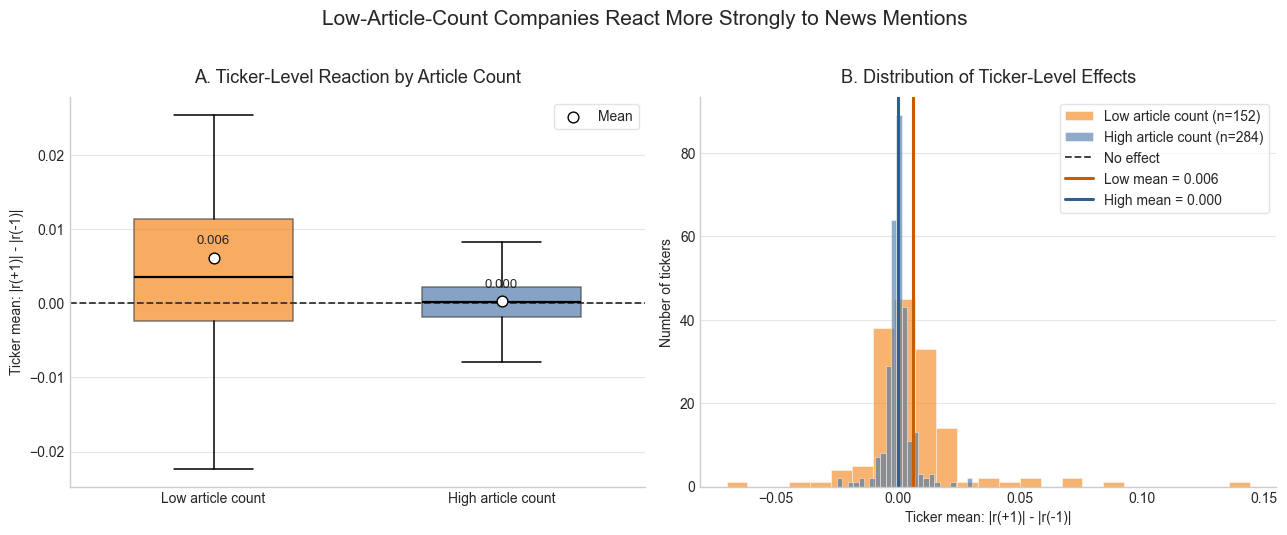

In [23]:
plt.style.use('seaborn-v0_8-whitegrid')

small_effect = ticker_effects.loc[ticker_effects['size_group'] == 'small', 'mean_abs_change'].dropna()
large_effect = ticker_effects.loc[ticker_effects['size_group'] == 'large', 'mean_abs_change'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))

# --- Panel A: simple boxplot by group ---
data = [small_effect, large_effect]
colors = ['#F58518', '#4C78A8']

box = axes[0].boxplot(
    data,
    labels=['Low article count', 'High article count'],
    showfliers=False,
    patch_artist=True,
    widths=0.55,
    medianprops=dict(color='black', linewidth=1.6),
    boxprops=dict(linewidth=1.1),
    whiskerprops=dict(linewidth=1.1),
    capprops=dict(linewidth=1.1),
)

for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.68)
    patch.set_edgecolor('#444444')

group_means = [small_effect.mean(), large_effect.mean()]
axes[0].scatter(
    [1, 2],
    group_means,
    color='white',
    edgecolor='black',
    s=60,
    zorder=3,
    label='Mean',
)

for i, mean_val in enumerate(group_means, start=1):
    axes[0].annotate(
        f'{mean_val:.3f}',
        xy=(i, mean_val),
        xytext=(0, 10),
        textcoords='offset points',
        ha='center',
        fontsize=9.5,
    )

axes[0].axhline(0, color='#333333', linestyle='--', linewidth=1.3)
axes[0].set_ylabel('Ticker mean: |r(+1)| - |r(-1)|')
axes[0].set_title('A. Ticker-Level Reaction by Article Count', fontsize=13, pad=10)
axes[0].legend(frameon=True, facecolor='white', edgecolor='#DDDDDD', loc='upper right')


# --- Panel B: histogram  ---
for group, color, label in [
    ('small', '#F58518', f'Low article count (n={len(small_effect):,})'),
    ('large', '#4C78A8', f'High article count (n={len(large_effect):,})'),
]:
    x = ticker_effects.loc[ticker_effects['size_group'] == group, 'mean_abs_change'].dropna()
    axes[1].hist(
        x,
        bins=25,
        alpha=0.62,
        label=label,
        color=color,
        edgecolor='white',
        linewidth=0.5,
    )

axes[1].axvline(0, color='#333333', linestyle='--', linewidth=1.3, label='No effect')
axes[1].axvline(small_effect.mean(), color='#C75D00', linewidth=2.2, label=f'Low mean = {small_effect.mean():.3f}')
axes[1].axvline(large_effect.mean(), color='#2F5F8F', linewidth=2.2, label=f'High mean = {large_effect.mean():.3f}')

axes[1].set_xlabel('Ticker mean: |r(+1)| - |r(-1)|')
axes[1].set_ylabel('Number of tickers')
axes[1].set_title('B. Distribution of Ticker-Level Effects', fontsize=13, pad=10)
axes[1].legend(frameon=True, facecolor='white', edgecolor='#DDDDDD')

for ax in axes:
    ax.grid(axis='y', color='#E6E6E6')
    ax.grid(axis='x', visible=False)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    ax.spines['left'].set_color('#CCCCCC')
    ax.spines['bottom'].set_color('#CCCCCC')

fig.suptitle(
    'Low-Article-Count Companies React More Strongly to News Mentions',
    fontsize=15,
    y=1.02,
)

plt.tight_layout()
plt.savefig(HERE / 'news_mention_size_event_study.png', dpi=180, bbox_inches='tight')
plt.show()

## 10. Save outputs

In [24]:
event_windows.to_csv(HERE / 'news_mention_size_event_windows.csv', index=False)
ticker_effects.to_csv(HERE / 'news_mention_size_ticker_effects.csv', index=False)
pd.Series(main_results).to_csv(HERE / 'news_mention_size_main_test.csv')
within_results.to_csv(HERE / 'news_mention_size_within_group_tests.csv')

## Interpretation

The news-mention size event study supports the hypothesis that low-article-count companies react more strongly to news mentions than high-article-count companies.

The main test compares the ticker-level average reaction:

```text
mean_abs_change = average(|r(+1)| - |r(-1)|)
```

between low-article-count and high-article-count companies. The low-article-count group has a larger mean reaction than the high-article-count group. Since the normality and equal-variance assumptions are rejected, we use Welch's two-sample t-test as the main test. The result is significant, and the Mann-Whitney robustness check gives the same conclusion.

The within-group tests clarify the result. For high-article-count companies, the post-mention absolute-return increase is not statistically significant. For low-article-count companies, the increase is significant under both the one-sample t-test and the Wilcoxon robustness check.

This suggests that a news mention is more informative for companies that are rarely mentioned. For highly covered companies, an additional article is less surprising and does not meaningfully change next-day price movement. For low-article-count companies, a mention is a stronger attention shock and is followed by a larger stock reaction.

The main conclusion is that news mentions affect low-visibility companies more strongly than high-visibility companies, supporting the idea that article count acts as a proxy for market visibility and information saturation.
```